# End-to-End ResNet Compare (2-class vs 7-class)
이 노트북은 멀티프로세스 `.py` 학습 스크립트를 실행하고 history를 같은 형식으로 비교 시각화합니다.

In [1]:
import sys
from pathlib import Path

BASE = Path(r"c:\\Users\\ldy34\\Desktop\\Face")
ML = BASE / "ML"
VENV_PY = BASE / ".venv" / "Scripts" / "python.exe"

print("Current Python:", sys.executable)
print("Project venv:", VENV_PY)
if "Face\\.venv\\Scripts\\python.exe" not in sys.executable.replace('/', '\\'):
    print("[Warn] 현재 커널이 .venv가 아닙니다. 학습은 .venv python으로 실행되므로 진행은 가능하지만, 시각화 셀 패키지 오류가 날 수 있습니다.")

Current Python: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe
Project venv: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe


In [2]:
import subprocess

# 필요 시 노트북 커널 쪽 패키지 설치
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "tqdm"], check=False)
print("Notebook deps check done")

Notebook deps check done


In [3]:
import subprocess

TRAIN2 = ML / "train_resnet_2class_mp.py"
TRAIN7 = ML / "train_resnet_7class_mp.py"

BIN_MODEL = ML / "emotion_resnet_best.pth"
MC_MODEL = ML / "emotion_resnet_7class_best.pth"

cmd2 = [
    str(VENV_PY), str(TRAIN2),
    "--base-dir", str(BASE / "video"),
    "--epochs", "200",
    "--batch-size", "256",
    "--lr", "0.001",
    "--test-size", "0.15",
    "--max-per-zip", "5000",
    "--workers", "8",
    "--out", str(BIN_MODEL),
]

cmd7 = [
    str(VENV_PY), str(TRAIN7),
    "--base-dir", str(BASE / "video"),
    "--epochs", "200",
    "--batch-size", "256",
    "--lr", "0.001",
    "--test-size", "0.15",
    "--max-per-zip", "5000",
    "--workers", "8",
    "--out", str(MC_MODEL),
]

print("RUN 2-class:", " ".join(cmd2))
res2 = subprocess.run(cmd2, cwd=str(BASE), check=True)
print("2-class done:", res2)

print("RUN 7-class:", " ".join(cmd7))
res7 = subprocess.run(cmd7, cwd=str(BASE), check=True)
print("7-class done:", res7)

RUN 2-class: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_2class_mp.py --base-dir c:\Users\ldy34\Desktop\Face\video --epochs 200 --batch-size 256 --lr 0.001 --test-size 0.15 --max-per-zip 5000 --workers 8 --out c:\Users\ldy34\Desktop\Face\ML\emotion_resnet_best.pth
2-class done: CompletedProcess(args=['c:\\Users\\ldy34\\Desktop\\Face\\.venv\\Scripts\\python.exe', 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\train_resnet_2class_mp.py', '--base-dir', 'c:\\Users\\ldy34\\Desktop\\Face\\video', '--epochs', '200', '--batch-size', '256', '--lr', '0.001', '--test-size', '0.15', '--max-per-zip', '5000', '--workers', '8', '--out', 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\emotion_resnet_best.pth'], returncode=0)
RUN 7-class: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_7class_mp.py --base-dir c:\Users\ldy34\Desktop\Face\video --epochs 200 --batch-size 256 --lr 0.001 --test-size 0.15 --max-per-zip 5000 --

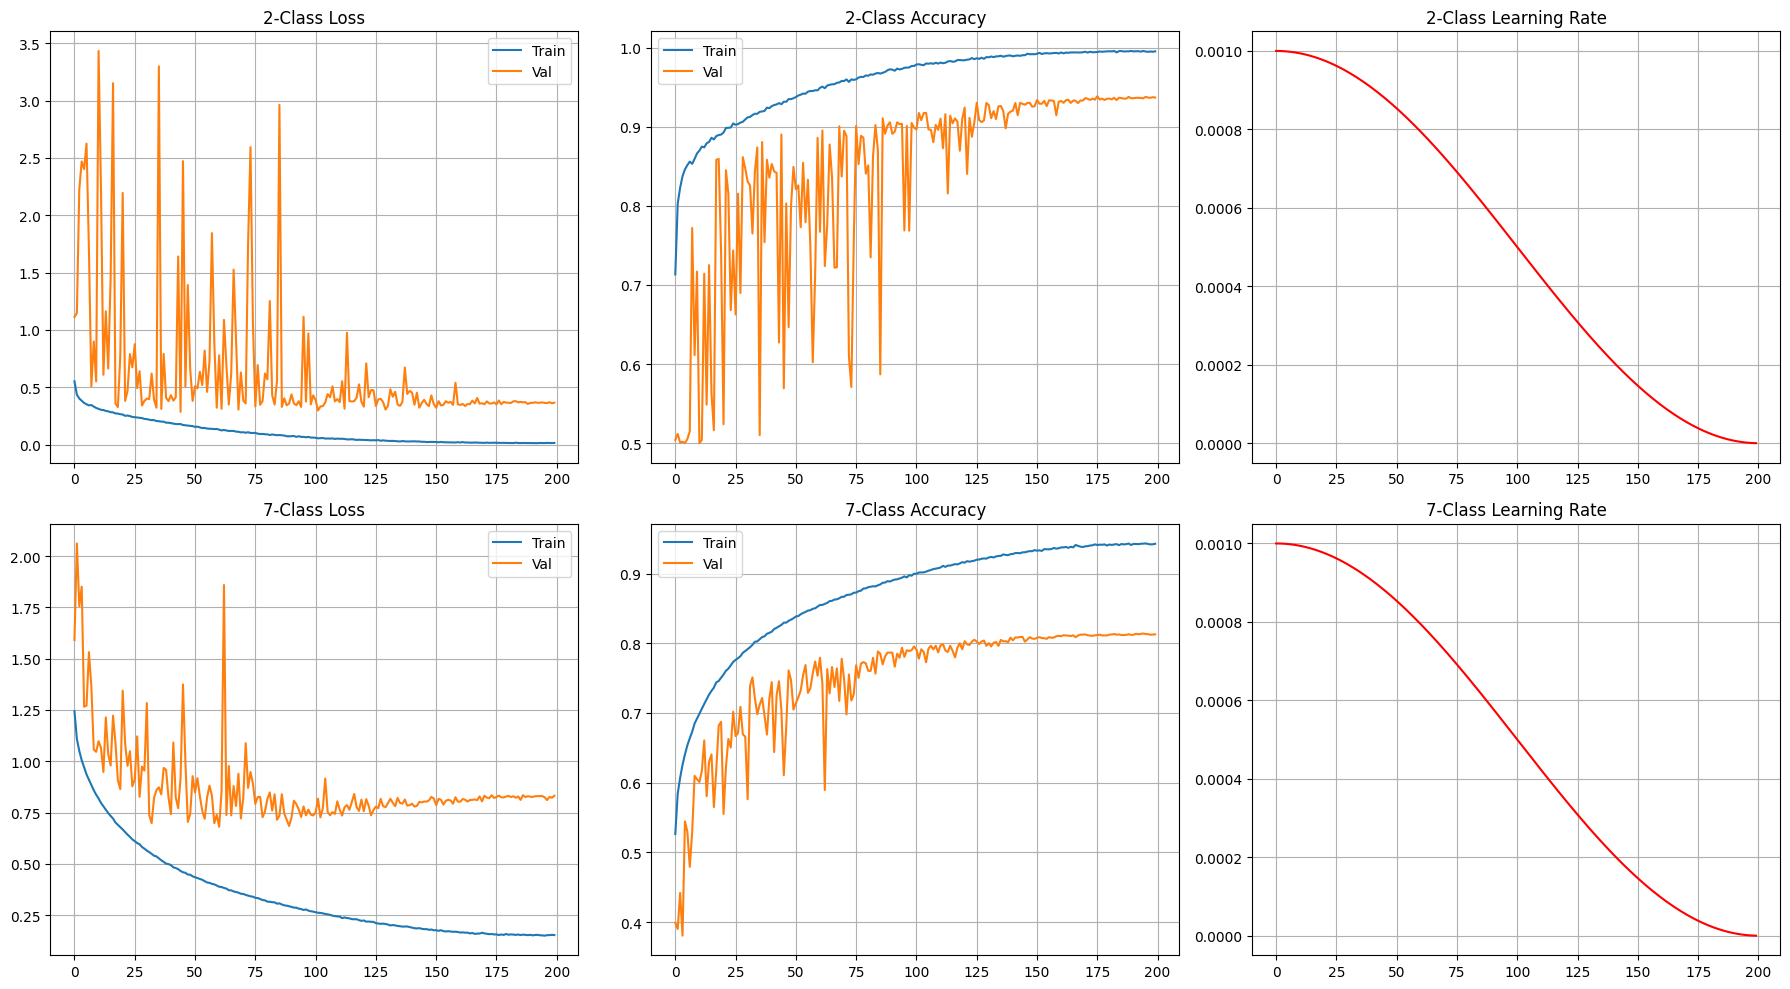

In [4]:
import json
import matplotlib.pyplot as plt

BIN_HIST = ML / "emotion_resnet_best_history.json"
MC_HIST = ML / "emotion_resnet_7class_best_history.json"

with open(BIN_HIST, "r", encoding="utf-8") as f:
    history_bin = json.load(f)
with open(MC_HIST, "r", encoding="utf-8") as f:
    history_7 = json.load(f)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.plot(history_bin['train_loss'], label='Train')
plt.plot(history_bin['test_loss'], label='Val')
plt.title('2-Class Loss')
plt.legend(); plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_bin['train_acc'], label='Train')
plt.plot(history_bin['test_acc'], label='Val')
plt.title('2-Class Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_bin['lr'], color='red')
plt.title('2-Class Learning Rate')
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_7['train_loss'], label='Train')
plt.plot(history_7['test_loss'], label='Val')
plt.title('7-Class Loss')
plt.legend(); plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_7['train_acc'], label='Train')
plt.plot(history_7['test_acc'], label='Val')
plt.title('7-Class Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(history_7['lr'], color='red')
plt.title('7-Class Learning Rate')
plt.grid(True)

plt.tight_layout()
plt.show()